<a href="https://colab.research.google.com/github/ranjetmahato416/-Lung-CT-Image-Classification-Using-Public-Medical-Imaging-Data-/blob/main/Desktop/Colab_Notebook/Notebook/Notebook_08_Dataset_Quality_Validation_%26_Patient_Level_Splitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1. Project Overview

In [1]:
# ============================================================
# Notebook 08
# Dataset Quality Validation & Patient-Level Splitting
# ============================================================

# This notebook performs:
#
# 1. Dataset validation
# 2. Duplicate detection
# 3. Image verification
# 4. Patient statistics
# 5. Dataset quality control
# 6. Patient-level train/validation/test split
#
# Input:
#    cnn_dataset.csv
#
# Output:
#    train.csv
#    validation.csv
#    test.csv
#
# ============================================================

##2. Mount Drive

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


##3. Import Libraries

In [2]:
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.model_selection import train_test_split

from PIL import Image

import hashlib

##4. Define Paths

In [3]:
DRIVE_ROOT = Path(
    "/content/drive/MyDrive/Dissertation"
)

PROCESSED_PATH = (
    DRIVE_ROOT /
    "Dataset" /
    "Processed"
)

CNN_PATH = (
    PROCESSED_PATH /
    "CNN_Dataset"
)

CSV_PATH = (
    PROCESSED_PATH /
    "cnn_dataset.csv"
)

print(CSV_PATH)

/content/drive/MyDrive/Dissertation/Dataset/Processed/cnn_dataset.csv


##5. Load Dataset

In [4]:
dataset = pd.read_csv(CSV_PATH)

print("Dataset shape:")

print(dataset.shape)

print()

dataset.head()

Dataset shape:
(1151, 5)



,PatientID,NoduleID,CancerLabel,LabelName,ImagePath
0,LIDC-IDRI-0078,1,0,Benign,C:\Users\Dell\Desktop\Colab_Notebook\Dataset\P...
1,LIDC-IDRI-0078,2,0,Benign,C:\Users\Dell\Desktop\Colab_Notebook\Dataset\P...
2,LIDC-IDRI-0078,4,1,Malignant,C:\Users\Dell\Desktop\Colab_Notebook\Dataset\P...
3,LIDC-IDRI-0069,1,0,Benign,C:\Users\Dell\Desktop\Colab_Notebook\Dataset\P...
4,LIDC-IDRI-0069,3,0,Benign,C:\Users\Dell\Desktop\Colab_Notebook\Dataset\P...


In [16]:
import os

# First, check if the base folder exists
base_path = '/content/drive/MyDrive/Dissertation/Dataset/Processed/CNN_Dataset/'

print(f"Checking base path: {base_path}")
print(f"Exists: {os.path.exists(base_path)}")

if os.path.exists(base_path):
    print("\nContents of CNN_Dataset:")
    print(os.listdir(base_path))

    # Check Benign folder
    benign_path = os.path.join(base_path, 'Benign')
    print(f"\nBenign folder exists: {os.path.exists(benign_path)}")
    if os.path.exists(benign_path):
        print(f"Number of files in Benign: {len(os.listdir(benign_path))}")
        print(f"First 5 files: {os.listdir(benign_path)[:5]}")

    # Check Malignant folder
    malignant_path = os.path.join(base_path, 'Malignant')
    print(f"\nMalignant folder exists: {os.path.exists(malignant_path)}")
    if os.path.exists(malignant_path):
        print(f"Number of files in Malignant: {len(os.listdir(malignant_path))}")
        print(f"First 5 files: {os.listdir(malignant_path)[:5]}")
else:
    print("\nSearching for CNN_Dataset folder...")
    !find /content -type d -name "CNN_Dataset" 2>/dev/null

Checking base path: /content/drive/MyDrive/Dissertation/Dataset/Processed/CNN_Dataset/
Exists: True

Contents of CNN_Dataset:
['Malignant', 'Benign']

Benign folder exists: True
Number of files in Benign: 991
First 5 files: ['LIDC-IDRI-0132_Nodule_006.png', 'LIDC-IDRI-0132_Nodule_002.png', 'LIDC-IDRI-0151_Nodule_001.png', 'LIDC-IDRI-0132_Nodule_001.png', 'LIDC-IDRI-0110_Nodule_001.png']

Malignant folder exists: True
Number of files in Malignant: 159
First 5 files: ['LIDC-IDRI-0132_Nodule_005.png', 'LIDC-IDRI-0078_Nodule_004.png', 'LIDC-IDRI-0060_Nodule_002.png', 'LIDC-IDRI-0060_Nodule_001.png', 'LIDC-IDRI-0055_Nodule_005.png']


In [17]:
import os
import pandas as pd
from tqdm import tqdm
import hashlib

# Your correct base path
correct_base = '/content/drive/MyDrive/Dissertation/Dataset/Processed/CNN_Dataset/'

# Fix paths by extracting filename and determining correct subfolder
def fix_image_path_correct(path):
    # Get just the filename
    filename = os.path.basename(path)

    # Check if the path already has the correct structure
    if '/Benign/' in path or '/Malignant/' in path:
        # If it already has the subfolder, just ensure the base path is correct
        if path.startswith('/content/drive/MyDrive/'):
            return path
        else:
            # Replace the base path
            relative = path.split('CNN_Dataset/')[-1]
            return os.path.join(correct_base, relative)

    # Determine which folder the file belongs to
    # Check if file exists in Benign folder
    benign_path = os.path.join(correct_base, 'Benign', filename)
    if os.path.exists(benign_path):
        return benign_path

    # Check if file exists in Malignant folder
    malignant_path = os.path.join(correct_base, 'Malignant', filename)
    if os.path.exists(malignant_path):
        return malignant_path

    # If not found, try to determine from the original path
    if 'Benign' in path:
        return os.path.join(correct_base, 'Benign', filename)
    elif 'Malignant' in path:
        return os.path.join(correct_base, 'Malignant', filename)

    # If still not determined, return as is
    return path

# Apply the fix
dataset['ImagePath'] = dataset['ImagePath'].apply(fix_image_path_correct)

# Verify a few paths
print("Sample fixed paths:")
for i in range(min(5, len(dataset))):
    path = dataset.iloc[i]['ImagePath']
    print(f"{path}")
    print(f"  Exists: {os.path.exists(path)}")
    print()

# Check all files
missing = []
for idx, path in enumerate(dataset['ImagePath']):
    if not os.path.exists(path):
        missing.append(idx)

if len(missing) == 0:
    print("✅ All files found! Proceeding with duplicate detection.")
else:
    print(f"⚠️ {len(missing)} files still missing")
    print("Sample missing files:")
    for idx in missing[:5]:
        print(f"  {dataset.iloc[idx]['ImagePath']}")

# Now run your duplicate detection
def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.sha256(f.read()).hexdigest()

hashes = {}
duplicates = []

for path in tqdm(dataset['ImagePath'], desc="Hashing images"):
    try:
        h = file_hash(path)
        if h in hashes:
            duplicates.append((hashes[h], path))
        else:
            hashes[h] = path
    except FileNotFoundError:
        print(f"File not found: {path}")
        continue

print("Duplicate images:", len(duplicates))

Sample fixed paths:
/content/drive/MyDrive/Dissertation/Dataset/Processed/CNN_Dataset/Benign/LIDC-IDRI-0078_Nodule_001.png
  Exists: True

/content/drive/MyDrive/Dissertation/Dataset/Processed/CNN_Dataset/Benign/LIDC-IDRI-0078_Nodule_002.png
  Exists: True

/content/drive/MyDrive/Dissertation/Dataset/Processed/CNN_Dataset/Malignant/LIDC-IDRI-0078_Nodule_004.png
  Exists: True

/content/drive/MyDrive/Dissertation/Dataset/Processed/CNN_Dataset/Benign/LIDC-IDRI-0069_Nodule_001.png
  Exists: True

/content/drive/MyDrive/Dissertation/Dataset/Processed/CNN_Dataset/Benign/LIDC-IDRI-0069_Nodule_003.png
  Exists: True

✅ All files found! Proceeding with duplicate detection.


Hashing images: 100%|██████████| 1151/1151 [09:10<00:00,  2.09it/s]

Duplicate images: 1


##6. Check Missing Values

In [8]:
print("Missing values")

print()

print(dataset.isnull().sum())

Missing values

PatientID      0
NoduleID       0
CancerLabel    0
LabelName      0
ImagePath      0
dtype: int64


##7. Dataset Summary

In [9]:
print("=" * 60)

print("DATASET SUMMARY")

print("=" * 60)

print()

print("Patients:")

print(dataset.PatientID.nunique())

print()

print("Images:")

print(len(dataset))

print()

print("Class Distribution")

print(dataset.LabelName.value_counts())

print()

print("Cancer Labels")

print(dataset.CancerLabel.value_counts())

DATASET SUMMARY

Patients:
435

Images:
1151

Class Distribution
LabelName
Benign       992
Malignant    159
Name: count, dtype: int64

Cancer Labels
CancerLabel
0    992
1    159
Name: count, dtype: int64


##8. Verify Image Files

In [10]:
# ============================================================
# Section 8 - Verify Image Files
# ============================================================

missing = []
corrupted = []

for path in tqdm(dataset["ImagePath"], desc="Checking images"):

    path = Path(path)

    if not path.exists():
        missing.append(str(path))
        continue

    img = cv2.imread(str(path))

    if img is None:
        corrupted.append(str(path))


print("="*60)

print("Missing images :", len(missing))
print("Corrupted images:", len(corrupted))

Checking images: 100%|██████████| 1151/1151 [00:00<00:00, 74671.22it/s]

Missing images : 1151
Corrupted images: 0


##9. Duplicate Patient-Nodule Check

In [9]:
# ============================================================
# Section 9 - Duplicate Nodule Check
# ============================================================

duplicates = dataset.duplicated(
    subset=["PatientID", "NoduleID"]
)

print("Duplicate nodules:", duplicates.sum())

if duplicates.sum() > 0:
    display(dataset[duplicates])

Duplicate nodules: 1


,PatientID,NoduleID,CancerLabel,LabelName,ImagePath
1150,LIDC-IDRI-0127,1,0,Benign,C:\Users\Dell\Desktop\Colab_Notebook\Dataset\P...


##10. Duplicate Image Detection

In [18]:
# ============================================================
# Section 10 - Duplicate Image Detection
# ============================================================

def file_hash(path):

    with open(path, "rb") as f:
        return hashlib.sha256(
            f.read()
        ).hexdigest()


hashes = {}

duplicates = []

for path in tqdm(dataset["ImagePath"], desc="Hashing images"):

    h = file_hash(path)

    if h in hashes:

        duplicates.append(
            (
                hashes[h],
                path
            )
        )

    else:

        hashes[h] = path


print("Duplicate images:", len(duplicates))

Hashing images: 100%|██████████| 1151/1151 [00:02<00:00, 395.89it/s]

Duplicate images: 1


##11. Image Statistics

In [19]:
# ============================================================
# Section 11 - Dataset Image Statistics
# ============================================================

means = []
stds = []

mins = []
maxs = []

for path in tqdm(dataset["ImagePath"], desc="Statistics"):

    img = cv2.imread(str(path))

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    means.append(img.mean())

    stds.append(img.std())

    mins.append(img.min())

    maxs.append(img.max())


print("="*60)

print("Mean intensity : %.2f" % np.mean(means))

print("Std intensity  : %.2f" % np.mean(stds))

print("Minimum pixel  :", np.min(mins))

print("Maximum pixel  :", np.max(maxs))

Statistics: 100%|██████████| 1151/1151 [00:06<00:00, 174.56it/s]

Mean intensity : 103.32
Std intensity  : 69.36
Minimum pixel  : 0
Maximum pixel  : 255


##12. Patient Distribution

In [20]:
# ============================================================
# Section 12 - Nodules Per Patient
# ============================================================

patient_counts = (
    dataset
    .groupby("PatientID")
    .size()
    .sort_values(ascending=False)
)

print(patient_counts.head(20))

PatientID
LIDC-IDRI-0049    14
LIDC-IDRI-0129    14
LIDC-IDRI-0045    12
LIDC-IDRI-0491    10
LIDC-IDRI-0012    10
LIDC-IDRI-0164    10
LIDC-IDRI-0179    10
LIDC-IDRI-0450     9
LIDC-IDRI-0398     9
LIDC-IDRI-0487     9
LIDC-IDRI-0334     9
LIDC-IDRI-0305     8
LIDC-IDRI-0356     8
LIDC-IDRI-0042     8
LIDC-IDRI-0415     8
LIDC-IDRI-0394     8
LIDC-IDRI-0358     8
LIDC-IDRI-0201     7
LIDC-IDRI-0195     7
LIDC-IDRI-0298     7
dtype: int64


####Visualize

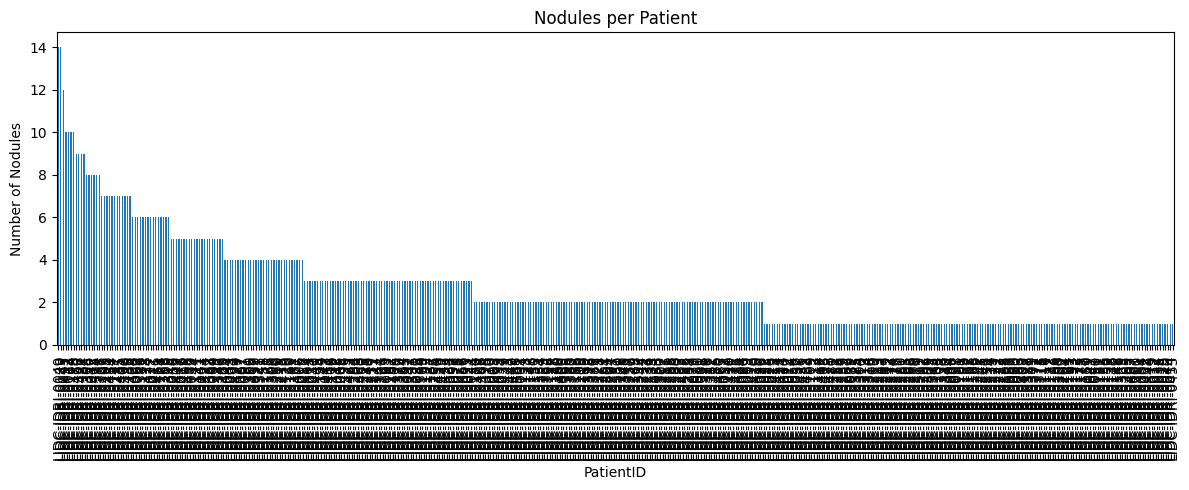

In [21]:
plt.figure(figsize=(12,5))

patient_counts.plot(kind="bar")

plt.ylabel("Number of Nodules")

plt.title("Nodules per Patient")

plt.tight_layout()

plt.show()

##13. Image Size Verification

In [22]:
# ============================================================
# Section 13 - Verify Image Size
# ============================================================

sizes = []

for path in dataset["ImagePath"]:

    img = cv2.imread(path)

    sizes.append(img.shape)

sizes = np.array(sizes)

unique_sizes = np.unique(sizes, axis=0)

print(unique_sizes)

[[128 128   3]]


##14. Investigate the Duplicate

In [23]:
# ============================================================
# Section 14 - Investigate Duplicate Nodule
# ============================================================

duplicates = dataset[
    dataset.duplicated(
        subset=["PatientID", "NoduleID"],
        keep=False
    )
]

duplicates.sort_values(
    ["PatientID", "NoduleID"]
)

,PatientID,NoduleID,CancerLabel,LabelName,ImagePath
1149,LIDC-IDRI-0127,1,0,Benign,/content/drive/MyDrive/Dissertation/Dataset/Pr...
1150,LIDC-IDRI-0127,1,0,Benign,/content/drive/MyDrive/Dissertation/Dataset/Pr...


##15. Compare the Two Images

In [24]:
dup = duplicates.reset_index(drop=True)

img1 = cv2.imread(dup.loc[0, "ImagePath"])
img2 = cv2.imread(dup.loc[1, "ImagePath"])

print(np.array_equal(img1, img2))

True


##16. Display Both Images

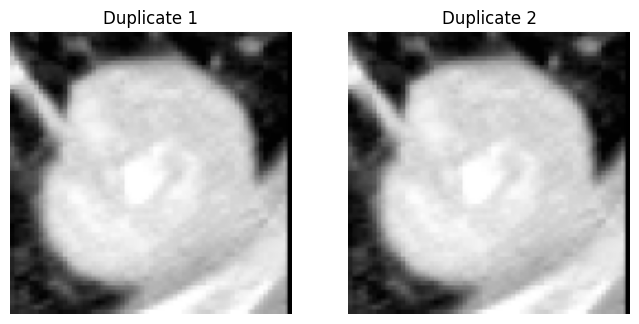

In [25]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
plt.title("Duplicate 1")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.title("Duplicate 2")
plt.axis("off")

plt.show()

####Remove Duplicate

In [26]:
dataset = dataset.drop_duplicates(
    subset=["PatientID", "NoduleID"]
).reset_index(drop=True)

print(dataset.shape)

(1150, 5)


####Save the Clean Dataset

In [27]:
dataset.to_csv(
    CSV_PATH,
    index=False
)

print("Dataset updated.")

Dataset updated.


##18. Patient-Level Split

In [28]:
# ============================================================
# Section 17 - Patient-Level Split
# ============================================================

patients = sorted(
    dataset["PatientID"].unique()
)

print("Patients:", len(patients))

Patients: 435


In [29]:
train_patients, temp_patients = train_test_split(
    patients,
    test_size=0.30,
    random_state=42
)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=42
)

print("Train:", len(train_patients))
print("Validation:", len(val_patients))
print("Test:", len(test_patients))

Train: 304
Validation: 65
Test: 66


##18. Build the Three Datasets

In [30]:
train_df = dataset[
    dataset.PatientID.isin(train_patients)
].reset_index(drop=True)

validation_df = dataset[
    dataset.PatientID.isin(val_patients)
].reset_index(drop=True)

test_df = dataset[
    dataset.PatientID.isin(test_patients)
].reset_index(drop=True)

print(train_df.shape)
print(validation_df.shape)
print(test_df.shape)

(808, 5)
(182, 5)
(160, 5)


##19. Verify No Patient Leakage

In [31]:
train_ids = set(train_df.PatientID)
val_ids = set(validation_df.PatientID)
test_ids = set(test_df.PatientID)

print("Train ∩ Validation:", len(train_ids & val_ids))
print("Train ∩ Test:", len(train_ids & test_ids))
print("Validation ∩ Test:", len(val_ids & test_ids))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


##20. Class Distribution Across Splits

In [32]:
# ============================================================
# Section 20 - Class Distribution
# ============================================================

print("=" * 60)

print("TRAIN")

print(train_df["LabelName"].value_counts())

print()

print("VALIDATION")

print(validation_df["LabelName"].value_counts())

print()

print("TEST")

print(test_df["LabelName"].value_counts())

TRAIN
LabelName
Benign       704
Malignant    104
Name: count, dtype: int64

VALIDATION
LabelName
Benign       150
Malignant     32
Name: count, dtype: int64

TEST
LabelName
Benign       137
Malignant     23
Name: count, dtype: int64


####Visualization

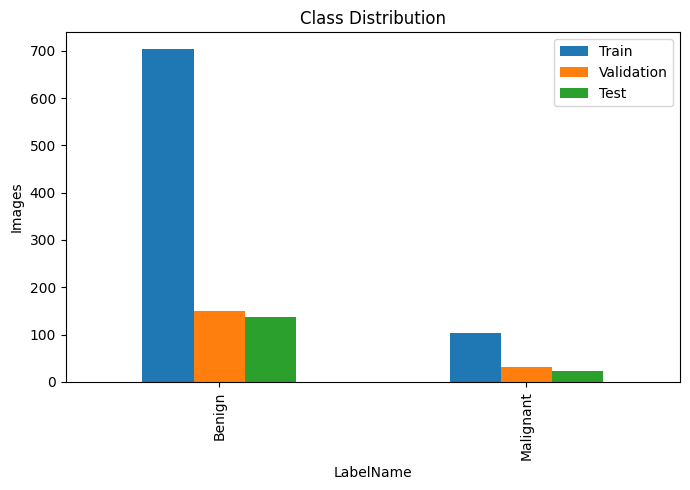

In [33]:
fig, ax = plt.subplots(figsize=(7,5))

summary = pd.DataFrame({
    "Train": train_df["LabelName"].value_counts(),
    "Validation": validation_df["LabelName"].value_counts(),
    "Test": test_df["LabelName"].value_counts()
}).fillna(0)

summary.plot(kind="bar", ax=ax)

plt.ylabel("Images")

plt.title("Class Distribution")

plt.tight_layout()

plt.show()

##21. Save the Splits

In [34]:
# ============================================================
# Section 21 - Save CSV Files
# ============================================================

train_csv = PROCESSED_PATH / "train.csv"

validation_csv = PROCESSED_PATH / "validation.csv"

test_csv = PROCESSED_PATH / "test.csv"


train_df.to_csv(train_csv, index=False)

validation_df.to_csv(validation_csv, index=False)

test_df.to_csv(test_csv, index=False)


print(train_csv)

print(validation_csv)

print(test_csv)

/content/drive/MyDrive/Dissertation/Dataset/Processed/train.csv
/content/drive/MyDrive/Dissertation/Dataset/Processed/validation.csv
/content/drive/MyDrive/Dissertation/Dataset/Processed/test.csv


##22. Verify Saved Files

In [35]:
train = pd.read_csv(train_csv)

val = pd.read_csv(validation_csv)

test = pd.read_csv(test_csv)


print("Train:", train.shape)

print("Validation:", val.shape)

print("Test:", test.shape)

Train: (808, 5)
Validation: (182, 5)
Test: (160, 5)


##23. Final Dataset Report

In [36]:
# ============================================================
# Section 23 - Final Dataset Report
# ============================================================

print("="*60)

print("FINAL DATASET REPORT")

print("="*60)

print()

print("Patients")

print(dataset.PatientID.nunique())

print()

print("Images")

print(len(dataset))

print()

print("Train")

print(len(train))

print()

print("Validation")

print(len(val))

print()

print("Test")

print(len(test))

print()

print("Benign")

print(dataset.LabelName.value_counts()["Benign"])

print()

print("Malignant")

print(dataset.LabelName.value_counts()["Malignant"])

FINAL DATASET REPORT

Patients
435

Images
1150

Train
808

Validation
182

Test
160

Benign
991

Malignant
159


##24. Final Random Quality Check

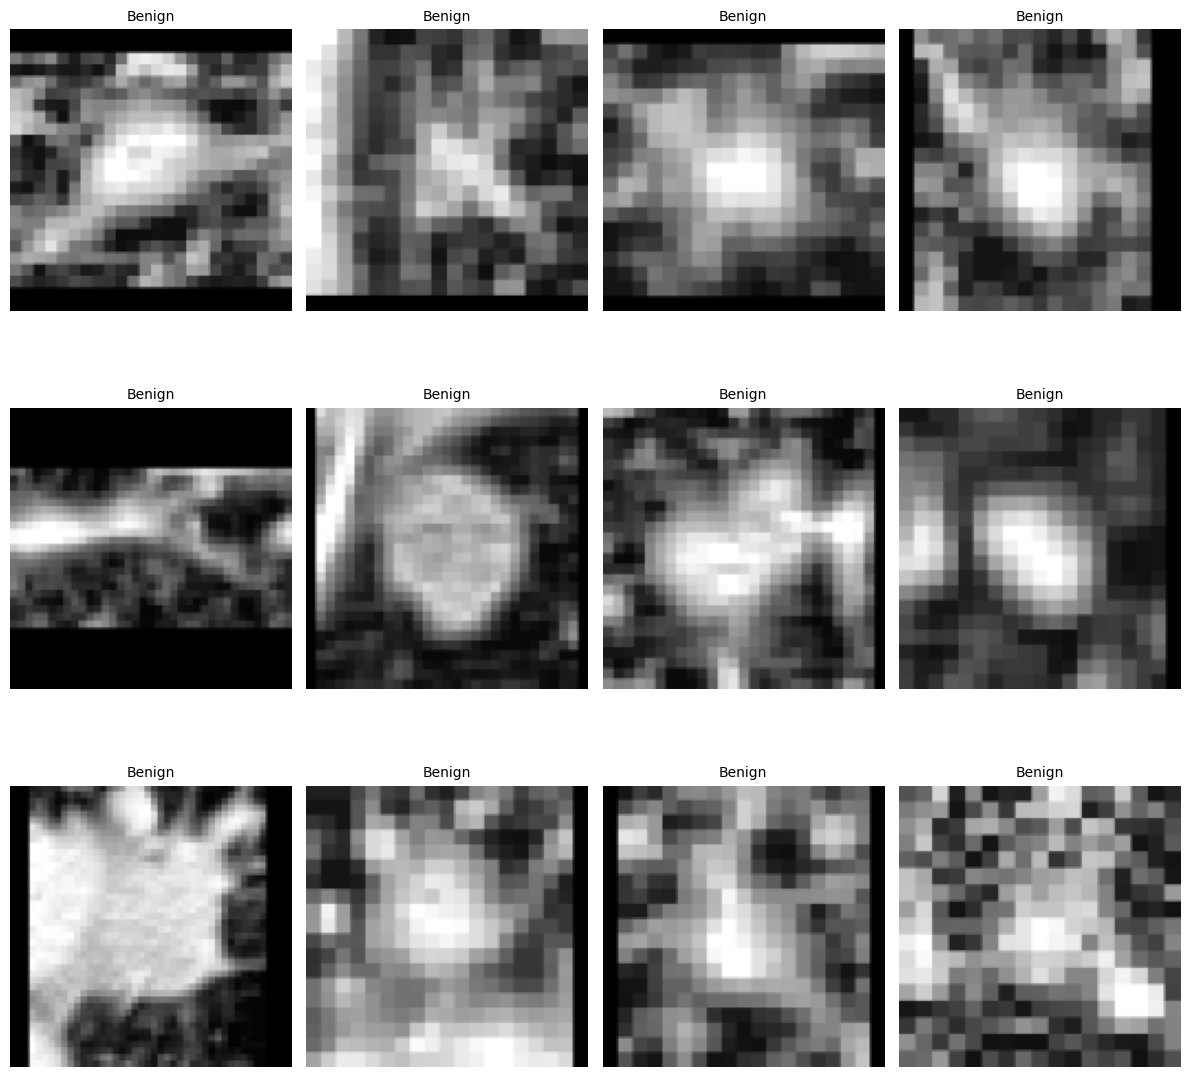

In [37]:
# ============================================================
# Section 24 - Random Image Verification
# ============================================================

samples = dataset.sample(12, random_state=42)

plt.figure(figsize=(12,12))

for i, (_, row) in enumerate(samples.iterrows()):

    img = cv2.imread(row["ImagePath"])

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3,4,i+1)

    plt.imshow(img)

    plt.title(row["LabelName"], fontsize=10)

    plt.axis("off")

plt.tight_layout()

plt.show()